# Pranay's Contribution

### custom preprocessing for LSTM

In [2]:
import pandas as pd


# Display all rows (no truncation)
pd.set_option('display.max_rows', None)

# Optional: Display all columns too (in case there are many)
pd.set_option('display.max_columns', None)
# Make sure pandas displays entire text content
pd.set_option('display.max_colwidth', None)  # Show full content of each cell


# === Load your dataset ===
data_path = '/Users/nithish/Downloads/Sentiment_Data.csv'
df = pd.read_csv(data_path, encoding='ISO-8859-1')

# === Basic Info ===
print("✅ First 100 rows:")
print(df.head(100))

print("\n📊 Column Names:", df.columns.tolist())

# === Class Distribution ===
label_col = 'label' if 'label' in df.columns else df.columns[-1]  # fallback to last column if unsure
print(f"\n🧾 Class Distribution ({label_col}):")
print(df[label_col].value_counts())

# === Text length analysis ===
text_col = 'text' if 'text' in df.columns else df.columns[0]  # fallback to first column if unsure
df['text_length'] = df[text_col].astype(str).apply(len)
print("\n✏️ Average Text Length:", df['text_length'].mean())

# === Unique Labels ===
print("\n🔢 Unique Labels:", df[label_col].nunique())



✅ First 100 rows:
                                                                                                                                                                                                                                                                                                              Tweet  \
0                                                                                             @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
1                                                                                           @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
2                                                

In [35]:
import pandas as pd
import re
import emoji
from tqdm import tqdm

# Load your dataset
data_path = '/Users/nithish/Downloads/Sentiment_Data.csv'
df = pd.read_csv(data_path, encoding='ISO-8859-1')

# Slang dictionary
slang_dict = {
    "u": "you", "r": "are", "lol": "laughing out loud", "brb": "be right back",
    "idk": "I don’t know", "btw": "by the way", "omg": "oh my god"
}
# Abbreviation set (same as slang_dict for simplicity)
abbr_dict = slang_dict

# Function to clean tweet
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)     # Remove mentions
    text = re.sub(r'#\w+', '', text)     # Remove hashtags
    text = re.sub(r'\s+', ' ', text)     # Extra spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special chars
    text = emoji.demojize(text)  # Convert emojis to words
    text = ' '.join([slang_dict.get(word, abbr_dict.get(word, word)) for word in text.split()])
    return text.strip()

# Apply cleaning
tqdm.pandas()
df['clean_text'] = df['Tweet'].astype(str).progress_apply(clean_text)



100%|██████████| 451332/451332 [00:27<00:00, 16625.88it/s]


In [36]:
# Tweets that are now empty after cleaning
empty_tweets = df[df['clean_text'].str.strip() == '']
print(f"❗ Empty Tweets: {len(empty_tweets)}")

# Very short tweets (under 3 words)
short_tweets = df[df['clean_text'].str.split().apply(len) < 3]
print(f"⚠️ Very Short Tweets (<3 words): {len(short_tweets)}")


❗ Empty Tweets: 10548
⚠️ Very Short Tweets (<3 words): 16070


In [37]:
import re

# Check for tweets made of mostly emojis
emoji_pattern = re.compile("(:[a-z_]+:)+")
only_emoji = df['clean_text'].apply(lambda x: bool(emoji_pattern.fullmatch(x.strip())))
print(f"🤖 Only Emojis: {only_emoji.sum()}")

# Check for non-English characters
non_english = df['clean_text'].apply(lambda x: bool(re.search("[^\x00-\x7F]", x)))
print(f"🌐 Non-English Tweets: {non_english.sum()}")


🤖 Only Emojis: 0
🌐 Non-English Tweets: 102


In [38]:
duplicate_count = df.duplicated(subset=['clean_text']).sum()
print(f"📄 Duplicate Cleaned Tweets: {duplicate_count}")


📄 Duplicate Cleaned Tweets: 91776


In [39]:
# Missing labels or tweets
missing = df[df['Sentiment'].isnull() | df['clean_text'].isnull()]
print(f"❌ Missing label/text rows: {len(missing)}")


❌ Missing label/text rows: 0


In [40]:
# Drop empties and NaNs
df = df[df['clean_text'].str.strip() != '']
df = df[df['clean_text'].str.split().apply(len) >= 3]
df = df.dropna(subset=['clean_text', 'Sentiment'])
df = df.drop_duplicates(subset=['clean_text'])
df = df[~non_english]  # remove non-English if you want

# Save cleaned version again
df.to_csv("preprocessed_sentiment_data_cleaned.csv", index=False)
print("✅ Final cleaned dataset saved.")


/var/folders/tc/l1djl3sj5wzc0_5r9gsl5xt00000gn/T/ipykernel_15167/2386087123.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[~non_english]  # remove non-English if you want


✅ Final cleaned dataset saved.


In [41]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("preprocessed_sentiment_data_cleaned.csv")
# Make sure pandas displays entire text content
pd.set_option('display.max_colwidth', None)  # Show full content of each cell

# Just to confirm it's loaded correctly
print("✅ Dataset Loaded. Shape:", df.shape)
print("🔍 Columns:", df.columns.tolist())
print(df.head(3))


✅ Dataset Loaded. Shape: (357126, 3)
🔍 Columns: ['Tweet', 'Sentiment', 'clean_text']
                                                                                                                                                                                                                   Tweet  \
0  @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
1                                                                                                                                                                 Freedom Convoy as InkBlot Test https://t.co/auLrduDpdI   
2                                       @mark_slapinski Well itâs pretty easy to see what their agenda is and Pierre has remained silent on the issues and he never actually fought for the convoy just did a photo op   

    Sentiment  \
0    Mild_Pos   


In [42]:
# Create a standard sentiment mapping
label_map = {
    'Strong_Pos': 'positive',
    'Mild_Pos': 'positive',
    'Weak_Pos': 'positive',
    'Strong_Neg': 'negative',
    'Mild_Neg': 'negative',
    'Weak_Neg': 'negative',
    'Neutral': 'neutral'
}

# Apply mapping
df['Sentiment'] = df['Sentiment'].map(label_map)

# Drop unmapped rows (if any)
df = df[df['Sentiment'].notnull()]
print("✅ Unique Sentiments after mapping:", df['Sentiment'].unique())


✅ Unique Sentiments after mapping: ['positive' 'neutral' 'negative']


In [43]:
# Drop duplicates based on clean text
df = df.drop_duplicates(subset=['clean_text'])
print("✅ Shape after removing duplicates:", df.shape)


✅ Shape after removing duplicates: (357126, 3)


📊 Class Distribution (after cleaning):
Sentiment
positive    236182
negative     68011
neutral      52933
Name: count, dtype: int64


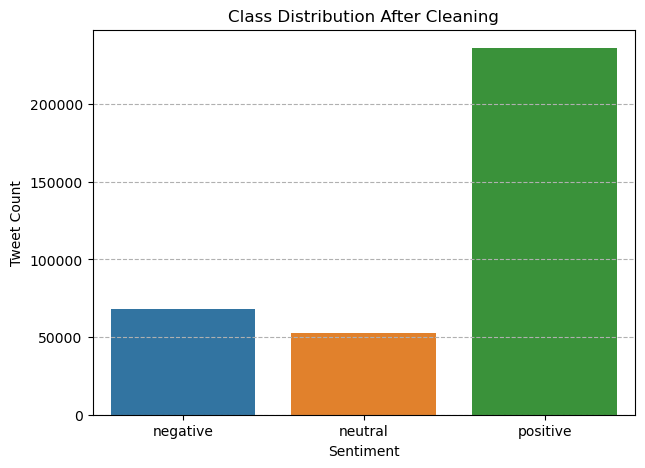


☁️ WordCloud Stats for negative:
- Total Words: 1916590
- Unique Words: 53258


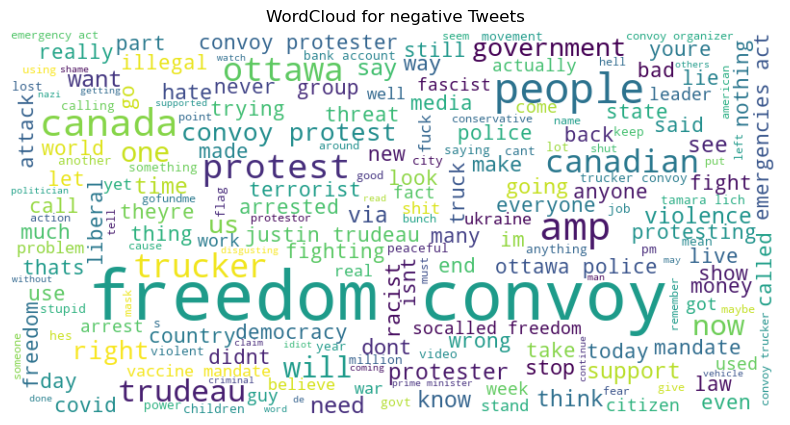


☁️ WordCloud Stats for neutral:
- Total Words: 1117323
- Unique Words: 53936


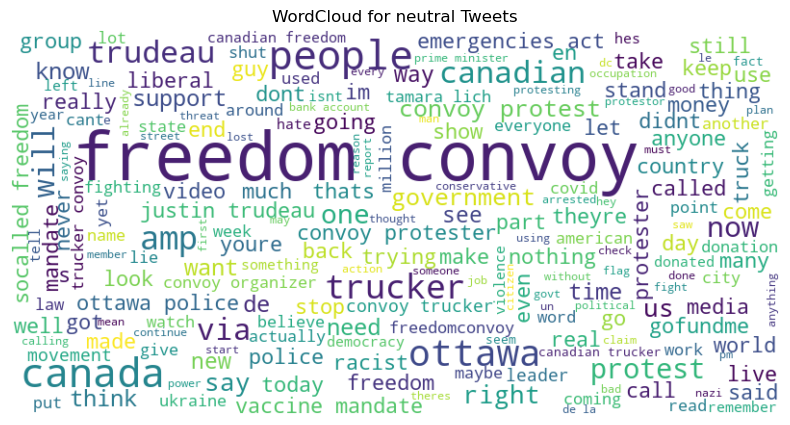


☁️ WordCloud Stats for positive:
- Total Words: 5666710
- Unique Words: 110830


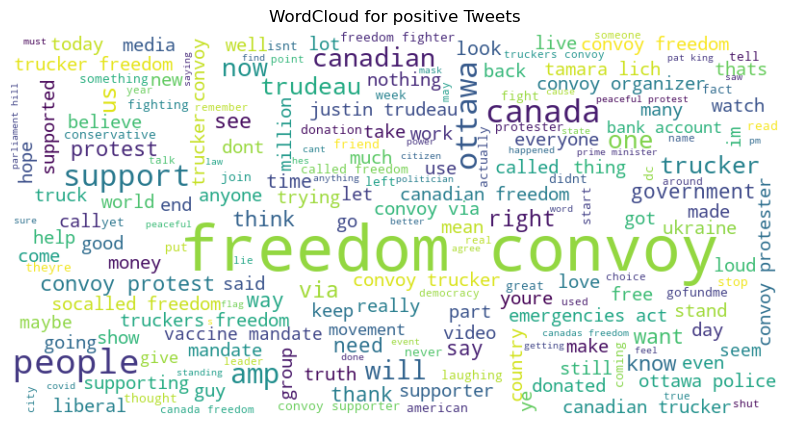


📏 Tweet Length Stats:
- Average tweet length: 24.36 words
- Max tweet length: 64 words
- Min tweet length: 3 words


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


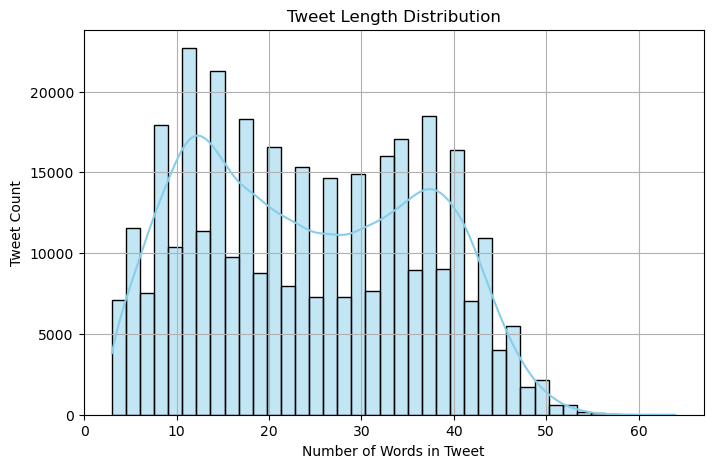

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# === Class Distribution ===
class_counts = df['Sentiment'].value_counts()
print("📊 Class Distribution (after cleaning):")
print(class_counts)

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Sentiment', order=['negative', 'neutral', 'positive'])
plt.title("Class Distribution After Cleaning")
plt.ylabel("Tweet Count")
plt.xlabel("Sentiment")
plt.grid(axis='y', linestyle='--')
plt.show()

# === WordClouds per Sentiment ===
for sentiment in ['negative', 'neutral', 'positive']:
    text_data = df[df['Sentiment'] == sentiment]['clean_text'].astype(str)
    total_words = text_data.str.split().apply(len).sum()
    unique_words = set(" ".join(text_data).split())

    print(f"\n☁️ WordCloud Stats for {sentiment}:")
    print(f"- Total Words: {total_words}")
    print(f"- Unique Words: {len(unique_words)}")

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text_data))

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud for {sentiment} Tweets")
    plt.show()

# === Tweet Length Distribution ===
df['text_len'] = df['clean_text'].astype(str).apply(lambda x: len(x.split()))
avg_len = df['text_len'].mean()
max_len = df['text_len'].max()
min_len = df['text_len'].min()

print(f"\n📏 Tweet Length Stats:")
print(f"- Average tweet length: {avg_len:.2f} words")
print(f"- Max tweet length: {max_len} words")
print(f"- Min tweet length: {min_len} words")

plt.figure(figsize=(8, 5))
sns.histplot(df['text_len'], bins=40, kde=True, color='skyblue')
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words in Tweet")
plt.ylabel("Tweet Count")
plt.grid(True)
plt.show()


In [45]:
import pandas as pd

# Load the cleaned file
df = pd.read_csv("/Users/nithish/Downloads/sentiment_lemmatized_tokenized.csv")
# Display all rows (no truncation)
pd.set_option('display.max_rows', None)

# Optional: Display all columns too (in case there are many)
pd.set_option('display.max_columns', None)
# Make sure pandas displays entire text content
pd.set_option('display.max_colwidth', None)  # Show full content of each cell
# Display first few rows
print(df.head(10))


                                                                                                                                                                                                                                                             Tweet  \
0                                            @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
1                                                                                                                                                                                                           Freedom Convoy as InkBlot Test https://t.co/auLrduDpdI   
2                                                                                 @mark_slapinski Well itâs pretty easy to see what their agenda is and Pierre has remained silent on the issues and he never actual

In [46]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

# === 1. Load CSV with correct encoding ===
file_path = "/Users/nithish/Downloads/sentiment_cleaned_final.csv"
df = pd.read_csv(file_path, encoding='utf-8')

# === 2. Initialize tools ===
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# === 3. Define text cleaning function ===
def clean_text(text):
    # Add space after punctuations before removing them
    text = re.sub(r'([a-zA-Z])([.?!])', r'\1 \2', text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove emojis and non-ASCII
    text = text.encode('ascii', 'ignore').decode('utf-8')
    # Remove punctuations and numbers
    text = re.sub(r'[^A-Za-z\s]', '', text)
    # Adds space before punctuations
    text = re.sub(r'([a-zA-Z])([.?!])', r'\1 \2', text)  

    # Lowercase
    text = text.lower()
    return text

# === 4. Apply full preprocessing ===
cleaned_texts = []
tokens_list = []
text_lengths = []

for text in tqdm(df['Tweet'], desc="🧼 Cleaning and Lemmatizing"):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    cleaned_texts.append(" ".join(tokens))
    tokens_list.append(tokens)
    text_lengths.append(len(tokens))

# === 5. Add new columns ===
df['clean_text'] = df['clean_text'].str.replace(r'\bamp\b', '', regex=True)
df['tokens'] = tokens_list
df['text_len'] = text_lengths



🧼 Cleaning and Lemmatizing: 100%|██████████| 357126/357126 [00:39<00:00, 9044.71it/s] 


## MODEL BUILDING

In [36]:
df.to_csv("/Users/nithish/Downloads/sentiment_cleaned_final.csv", index=False)
print("Dataset saved as 'sentiment_cleaned_final.csv'")

Dataset saved as 'sentiment_cleaned_final.csv'


In [47]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [48]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import gensim.downloader as api
w2v_pretrained = api.load("word2vec-google-news-300")

# ✅ Load the preprocessed data
df = pd.read_csv("/Users/nithish/Downloads/sentiment_lemmatized_tokenized.csv")

# ✅ Keep only the required columns
df = df[['clean_text', 'Sentiment']]

# ✅ Tokenize the clean text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# ✅ Pad sequences to uniform length
max_len = 64
X = pad_sequences(sequences, maxlen=max_len, padding='post')

# ✅ Convert Sentiment labels to one-hot vectors
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['Sentiment'].map(label_map).values
y = to_categorical(y, num_classes=3)

# ✅ Prepare the embedding matrix
embedding_dim = 300
word_index = tokenizer.word_index
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))

missing_count = 0
for word, i in word_index.items():
    if word in w2v_pretrained:
        embedding_matrix[i] = w2v_pretrained[word]
    else:
        missing_count += 1

print(f"✅ Embedding matrix ready. {missing_count} words not found in pretrained model.")


✅ Embedding matrix ready. 97539 words not found in pretrained model.


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from tensorflow.keras.utils import to_categorical

# Convert labels again (if not done already)
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['Sentiment'].map(label_map).values
y = to_categorical(y, num_classes=3)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Compute class weights
classes = np.argmax(y_train, axis=1)
weights = compute_class_weight(class_weight='balanced', classes=np.unique(classes), y=classes)
class_weights = {i: weights[i] for i in range(3)}

print("✅ Train-test split complete.")
print("⚖️ Class Weights:", class_weights)
print("📊 Train size:", len(X_train), "| Test size:", len(X_test))


✅ Train-test split complete.
⚖️ Class Weights: {0: 1.7503398159765788, 1: 2.2489000839630564, 2: 0.5040270376057567}
📊 Train size: 267844 | Test size: 89282


In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model = Sequential([
    Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=300,
        weights=[embedding_matrix],
        input_length=64,
        trainable=False  # Freeze embeddings
    ),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Print summary
model.summary()

# Optional: Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=128,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop]
)


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │    44,132,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,132,100 (168.35 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 44,132,100 (168.35 MB)

Epoch 1/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 226s 107ms/step - accuracy: 0.6043 - loss: 0.9038 - val_accuracy: 0.7406 - val_loss: 0.6866
Epoch 2/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 222s 106ms/step - accuracy: 0.7530 - loss: 0.7195 - val_accuracy: 0.7727 - val_loss: 0.6451
Epoch 3/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 213s 102ms/step - accuracy: 0.7748 - loss: 0.6607 - val_accuracy: 0.7454 - val_loss: 0.6772
Epoch 4/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 216s 103ms/step - accuracy: 0.7933 - loss: 0.6224 - val_accuracy: 0.8020 - val_loss: 0.5504
Epoch 5/5
2093/2093 ━━━━━━━━━━━━━━━━━━━━ 218s 104ms/step - accuracy: 0.8066 - loss: 0.5904 - val_accuracy: 0.8020 - val_loss: 0.6126


2791/2791 ━━━━━━━━━━━━━━━━━━━━ 60s 22ms/step


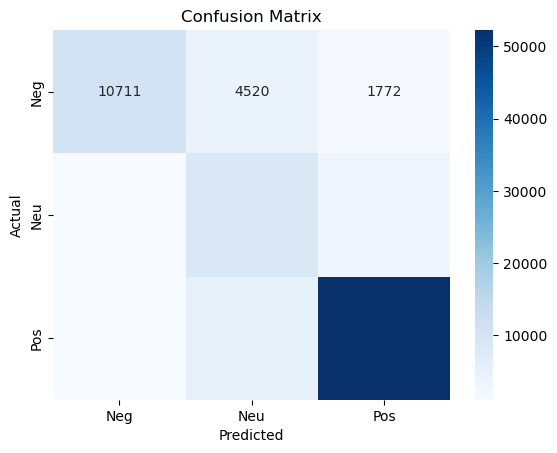

📊 Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.63      0.71     17003
     neutral       0.46      0.65      0.54     13233
    positive       0.91      0.88      0.90     59046

    accuracy                           0.80     89282
   macro avg       0.73      0.72      0.72     89282
weighted avg       0.83      0.80      0.81     89282

📈 AUC Score (macro): 0.9065
✅ Test Accuracy: 0.8020


In [51]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict class probabilities
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# 1. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 2. Classification Report (F1, Precision, Recall)
report = classification_report(y_true, y_pred, target_names=['negative', 'neutral', 'positive'])
print("📊 Classification Report:\n", report)

# 3. AUC Score (macro avg)
auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print(f"📈 AUC Score (macro): {auc:.4f}")

# 4. Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {acc:.4f}")


In [52]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# ======= Train Set Evaluation =======
y_train_pred_probs = model.predict(X_train, batch_size=512)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_train_true = np.argmax(y_train, axis=1)

print("📊 Train Set Evaluation:")
print(classification_report(y_train_true, y_train_pred, target_names=label_map.keys()))
print("📈 AUC Score (Train, macro):", roc_auc_score(y_train, y_train_pred_probs, average='macro'))
print("✅ Train Accuracy:", np.mean(y_train_pred == y_train_true))

# ======= Test Set Evaluation =======
y_test_pred_probs = model.predict(X_test, batch_size=512)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

print("\n📊 Test Set Evaluation:")
print(classification_report(y_test_true, y_test_pred, target_names=label_map.keys()))
print("📈 AUC Score (Test, macro):", roc_auc_score(y_test, y_test_pred_probs, average='macro'))
print("✅ Test Accuracy:", np.mean(y_test_pred == y_test_true))


524/524 ━━━━━━━━━━━━━━━━━━━━ 48s 92ms/step
📊 Train Set Evaluation:
              precision    recall  f1-score   support

    negative       0.84      0.65      0.73     51008
     neutral       0.47      0.67      0.56     39700
    positive       0.92      0.89      0.90    177136

    accuracy                           0.81    267844
   macro avg       0.74      0.74      0.73    267844
weighted avg       0.84      0.81      0.82    267844

📈 AUC Score (Train, macro): 0.9162437686439312
✅ Train Accuracy: 0.8107965830856767
175/175 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step

📊 Test Set Evaluation:
              precision    recall  f1-score   support

    negative       0.82      0.63      0.71     17003
     neutral       0.46      0.65      0.54     13233
    positive       0.91      0.88      0.90     59046

    accuracy                           0.80     89282
   macro avg       0.73      0.72      0.72     89282
weighted avg       0.83      0.80      0.81     89282

📈 AUC Score (Test, m

In [16]:
# Save model architecture, weights, and optimizer state
model.save("lstm_sentiment_model.h5")
print("✅ Model saved as 'lstm_sentiment_model.h5'")


✅ Model saved as 'lstm_sentiment_model.h5'


In [32]:
import pickle

# Save the tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved as 'tokenizer.pkl'")


✅ Tokenizer saved as 'tokenizer.pkl'


In [18]:
# Save the label mapping dictionary
with open("label_map.pkl", "wb") as f:
    pickle.dump(label_map, f)
print("✅ Label map saved as 'label_map.pkl'")



✅ Label map saved as 'label_map.pkl'


### LLM Prompts Used:
- for the given task breakdown it down into step by step process to achieve the goal.
- what are all the necessary preprocessing for the given sample of my data set as per my assignment task.
- can you give me robust code to preprocess the data save to the given path.
- ....
- for this metrics give a visual representation code..

# Nithish's Contribution:

# Model Tuning

In [53]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.utils import class_weight

# === Step 1: Define input shape ===
vocab_size = tokenizer.num_words if tokenizer.num_words else len(tokenizer.word_index) + 1
max_len = X_train.shape[1]

# === Step 2: Class Weights ===
y_train_labels = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))

# === Step 3: Build Model ===
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=max_len))
model.add(LSTM(units=128, dropout=0.5))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# === Step 4: EarlyStopping ===
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# === Step 5: Train ===
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=32,
                    class_weight=class_weight_dict,
                    callbacks=[early_stop],
                    verbose=1)


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
6697/6697 ━━━━━━━━━━━━━━━━━━━━ 525s 78ms/step - accuracy: 0.3195 - loss: 1.1008 - val_accuracy: 0.4367 - val_loss: 1.0364
Epoch 2/10
6697/6697 ━━━━━━━━━━━━━━━━━━━━ 521s 78ms/step - accuracy: 0.6664 - loss: 0.8301 - val_accuracy: 0.8313 - val_loss: 0.4757
Epoch 3/10
6697/6697 ━━━━━━━━━━━━━━━━━━━━ 520s 78ms/step - accuracy: 0.8150 - loss: 0.5371 - val_accuracy: 0.8179 - val_loss: 0.4995
Epoch 4/10
6697/6697 ━━━━━━━━━━━━━━━━━━━━ 525s 78ms/step - accuracy: 0.8483 - loss: 0.4553 - val_accuracy: 0.8178 - val_loss: 0.4926


In [54]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Evaluation Metrics
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

print("Accuracy:", accuracy_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))


2791/2791 ━━━━━━━━━━━━━━━━━━━━ 38s 13ms/step
Confusion Matrix:
 [[12406  2947  1650]
 [ 1547  8376  3310]
 [ 1067  4482 53497]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.77     17003
     Neutral       0.53      0.63      0.58     13233
    Positive       0.92      0.91      0.91     59046

    accuracy                           0.83     89282
   macro avg       0.76      0.76      0.75     89282
weighted avg       0.84      0.83      0.84     89282

Accuracy: 0.8319594095114357
AUC: 0.9203720428816372


In [58]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.utils import class_weight
import numpy as np

# === Input shape ===
vocab_size = tokenizer.num_words if tokenizer.num_words else len(tokenizer.word_index) + 1
max_len = X_train.shape[1]

# === Subset for Faster Training ===
X_train_small = X_train[:100000]
y_train_small = y_train[:100000]

# === Class Weights ===
y_train_labels = np.argmax(y_train_small, axis=1)
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train_labels),
                                                  y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))

# === Build Model ===
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=200))  # Embedding size = 200
model.add(LSTM(units=128, dropout=0.5))                     # LSTM units = 128
model.add(Dense(3, activation='softmax'))                   # 3-class softmax output

# === Compile ===
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# === EarlyStopping ===
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# === Train (faster with smaller dataset + larger batch) ===
history = model.fit(X_train_small, y_train_small,
                    validation_split=0.2,
                    epochs=10,
                    batch_size=64,  # ⬆️ faster than 32
                    class_weight=class_weight_dict,
                    callbacks=[early_stop],
                    verbose=1)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 185s 147ms/step - accuracy: 0.3107 - loss: 1.1023 - val_accuracy: 0.5527 - val_loss: 0.9824
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 179s 143ms/step - accuracy: 0.5694 - loss: 0.9387 - val_accuracy: 0.7677 - val_loss: 0.6311
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 178s 142ms/step - accuracy: 0.7858 - loss: 0.6055 - val_accuracy: 0.7692 - val_loss: 0.5777
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 177s 141ms/step - accuracy: 0.8409 - loss: 0.4541 - val_accuracy: 0.7776 - val_loss: 0.5670
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 175s 140ms/step - accuracy: 0.8668 - loss: 0.3694 - val_accuracy: 0.7918 - val_loss: 0.5607
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 178s 142ms/step - accuracy: 0.8923 - loss: 0.2989 - val_accuracy: 0.7890 - val_loss: 0.6113
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 177s 142ms/step - accuracy: 0.9143 - loss: 0.2356 - val_accuracy: 0.7778 - val_loss: 0.6757


In [59]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))

print("Accuracy:", accuracy_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))


2791/2791 ━━━━━━━━━━━━━━━━━━━━ 39s 14ms/step
Confusion Matrix:
 [[11668  3845  1490]
 [ 1761  8275  3197]
 [ 1359  6683 51004]]
Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.69      0.73     17003
     Neutral       0.44      0.63      0.52     13233
    Positive       0.92      0.86      0.89     59046

    accuracy                           0.79     89282
   macro avg       0.71      0.73      0.71     89282
weighted avg       0.82      0.79      0.80     89282

Accuracy: 0.7946394570014113
AUC: 0.9007720481735163


# Model Interpretability

In [60]:
from lime.lime_text import LimeTextExplainer
import numpy as np


In [66]:
# --- STEP 1: Reconstruct raw text from X_test ---
# Assumes: tokenizer is already fitted

# Create reverse map from index to word
reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}

def sequence_to_text(sequence):
    return ' '.join([reverse_word_map.get(i, '') for i in sequence if i != 0])

# Reconstruct list of sentences from X_test
raw_test_texts = [sequence_to_text(seq) for seq in X_test]

# --- STEP 2: Define prediction wrapper for LIME ---
from lime.lime_text import LimeTextExplainer
import tensorflow as tf
import numpy as np

class_names = ["Negative", "Neutral", "Positive"]

def predict_text(texts):
    # Tokenize and pad input
    seq = tokenizer.texts_to_sequences(texts)
    padded = tf.keras.preprocessing.sequence.pad_sequences(seq, maxlen=max_len)
    preds = model.predict(padded)
    return preds

# --- STEP 3: Choose a sample and run LIME ---
explainer = LimeTextExplainer(class_names=class_names)

# Pick any sentence index
sample_index = 40
sample_text = raw_test_texts[sample_index]

# Explain instance
exp = explainer.explain_instance(sample_text, predict_text, num_features=10, top_labels=3)

# --- STEP 4: Show output ---
exp.show_in_notebook(text=True)


157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


LLM Prompts:
- these are the metrics results for model building evaluate the model according to the results..
- model is taking too long for the 2nd iteration can you take a sample to make it faster to train?
- ... 
- help me with model interpretablilty.